## **Business Goal:** 
Predict and prevent delayed shipments before they occur, reducing operational cost

## Problem Statement

Shipment delays cause customer dissatisfaction and higher costs.  
The core objective is to **identify as many at-risk shipments as possible** before they go out, prioritizing catching more true delays (high recall for class 0)

In [22]:
# warnings
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Data Libraries
import pandas as pd
import numpy as np
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Sns Pallete
pallete = 'ch:start=.2,rot=-.3'

### Reading Data

In [25]:
data = pd.read_csv('data.csv')
data.drop(columns=['ID'], inplace=True)
data.columns = data.columns.str.replace('_', ' ').str.replace('.', '_').str.title().str.strip().str.replace(' ', '_')

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_Block      10999 non-null  object 
 1   Mode_Of_Shipment     10999 non-null  object 
 2   Customer_Care_Calls  10999 non-null  int64  
 3   Customer_Rating      10999 non-null  int64  
 4   Cost_Of_The_Product  10901 non-null  float64
 5   Prior_Purchases      10999 non-null  int64  
 6   Product_Importance   10845 non-null  object 
 7   Gender               10999 non-null  object 
 8   Discount_Offered     10999 non-null  int64  
 9   Weight_In_Gms        10860 non-null  float64
 10  Reached_On_Time_Y_N  10999 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 945.4+ KB


Missing value imputation

In [27]:
data.isna().sum()

Warehouse_Block          0
Mode_Of_Shipment         0
Customer_Care_Calls      0
Customer_Rating          0
Cost_Of_The_Product     98
Prior_Purchases          0
Product_Importance     154
Gender                   0
Discount_Offered         0
Weight_In_Gms          139
Reached_On_Time_Y_N      0
dtype: int64

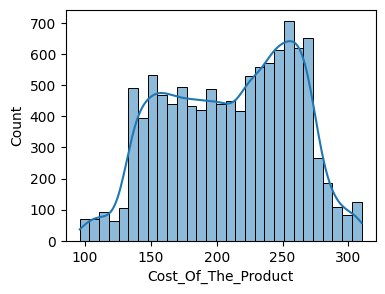

In [28]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Cost_Of_The_Product', kde=True, fill=True)
plt.show()

In [29]:
median_cost = data.Cost_Of_The_Product.median()
data.Cost_Of_The_Product.fillna(median_cost, inplace=True)

In [30]:
importance_mode = data.Product_Importance.mode()[0]
data.Product_Importance.fillna(importance_mode, inplace=True)

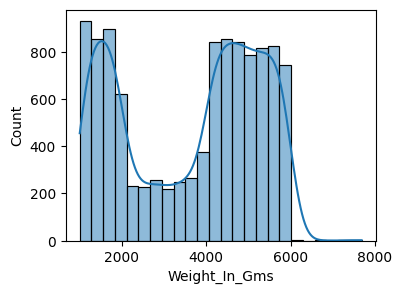

In [31]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Weight_In_Gms', kde=True, fill=True)
plt.show()

In [32]:
data.Weight_In_Gms.fillna(data.Weight_In_Gms.median(), inplace=True)

### Exploring Data

Exploring Categorical Variables

In [33]:
categorical_variables = ['Warehouse_Block', 'Mode_Of_Shipment', 'Product_Importance', 'Gender']

Warehouse Block

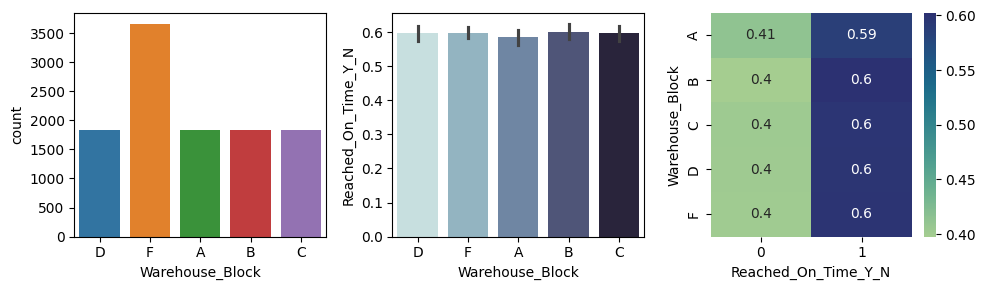

In [34]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Warehouse_Block', hue='Warehouse_Block')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Warehouse_Block', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Warehouse_Block, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Mode Of Shipment

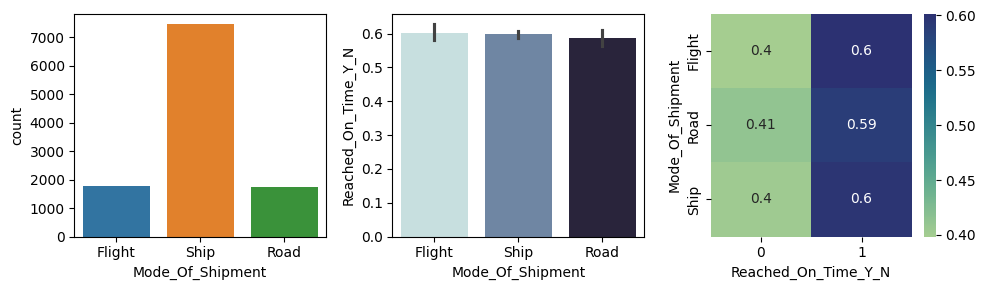

In [35]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Mode_Of_Shipment', hue='Mode_Of_Shipment')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Mode_Of_Shipment', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Mode_Of_Shipment, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Product Importance

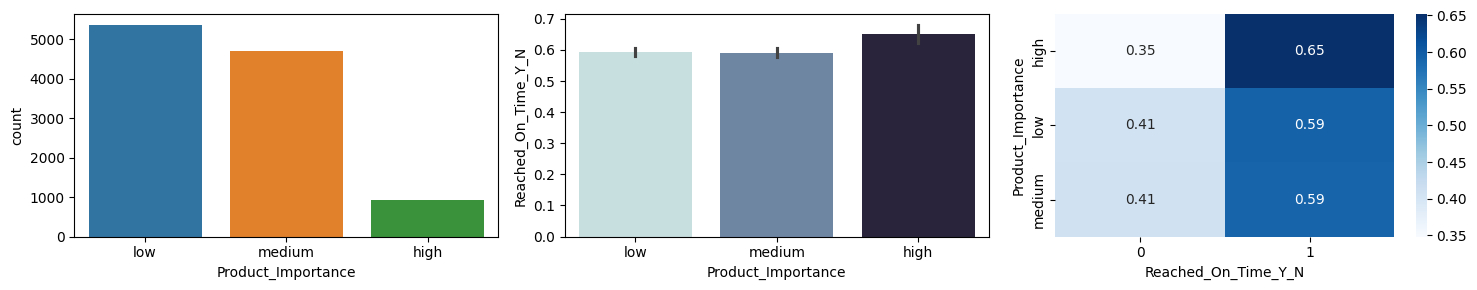

In [36]:
fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Product_Importance', hue='Product_Importance')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Product_Importance', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Product_Importance, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Gender

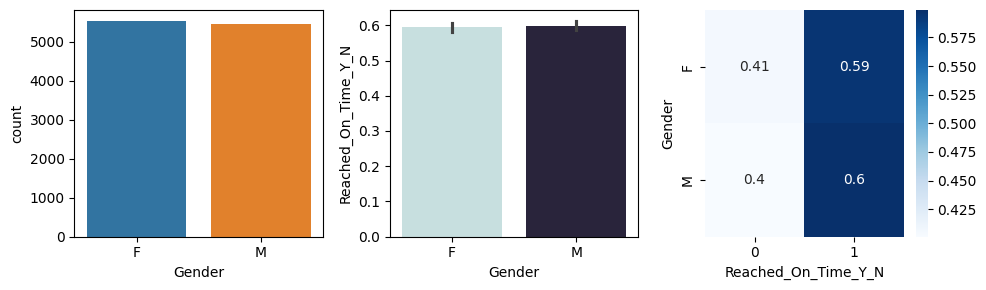

In [37]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Gender', hue='Gender')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Gender', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Gender, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Exploring Numerical Variables

In [38]:
numerical_columns = ['Customer_Care_Calls', 'Customer_Rating', 'Cost_Of_The_Product', 'Prior_Purchases', 'Weight_In_Gms', 'Reached_On_Time_Y_N']

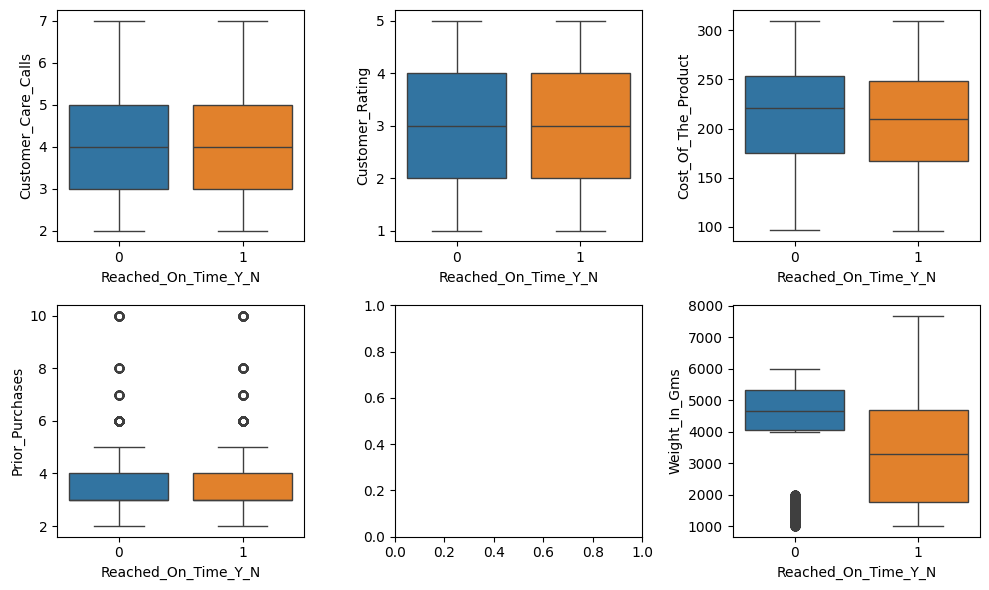

In [39]:
fig = plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
sns.boxplot(data=data, y='Customer_Care_Calls', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 2)
sns.boxplot(data=data, y='Customer_Rating', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 3)
sns.boxplot(data=data, y='Cost_Of_The_Product', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 4)
sns.boxplot(data=data, y='Prior_Purchases', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 5)
#sns.boxplot(data=data, y='Discount_Offered', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 6)
sns.boxplot(data=data, y='Weight_In_Gms', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.tight_layout()
plt.show()

In [40]:
data.drop(columns=['Discount_Offered'], inplace=True)

In [41]:
# Features showing relationshipt with state of shipment
# Cost of product
# Discount
# Weight

Correlation

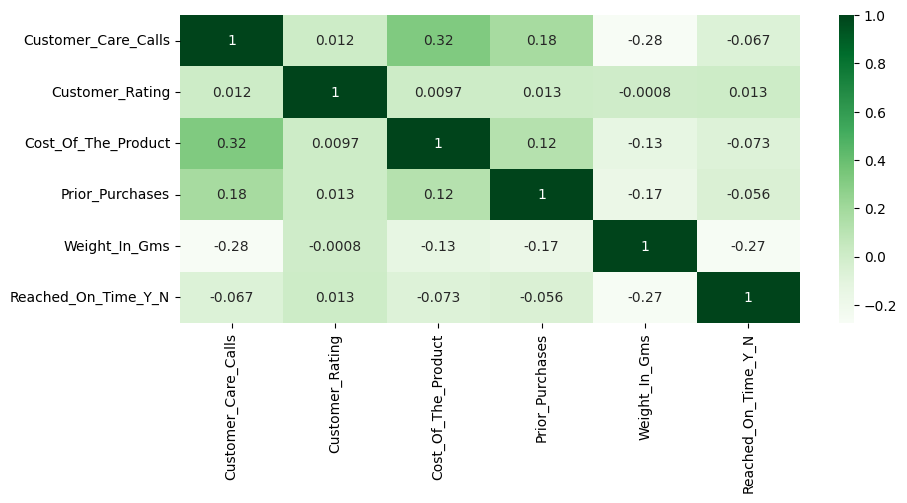

In [42]:
fig = plt.figure(figsize=(10, 4))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='Greens')
plt.show()

### Creating Features

In [43]:
categorical_variables.remove('Gender')

In [44]:
featured_data = pd.get_dummies(data=data, columns=categorical_variables).replace({True: 1, False: 0})

Gender

In [45]:
gender_map = {'M': 1, 'F': 0}
featured_data.Gender = featured_data.Gender.map(gender_map)

In [46]:
numerical_features = list(numerical_columns)
numerical_features.remove('Reached_On_Time_Y_N')

Splitting Data

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(featured_data, train_size=0.6, test_size=0.4, random_state=42)
y_train = X_train.pop('Reached_On_Time_Y_N')
y_test = X_test.pop('Reached_On_Time_Y_N')

### Scaling Data

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
scaler = MinMaxScaler()

In [50]:
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [51]:
X_train.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000
mean,0.417427,0.496818,0.538292,0.200636,0.501137,0.397836,0.165480,0.163964,0.166086,0.170935,0.333535,0.166843,0.158357,0.674799,0.083801,0.489923,0.426277
std,0.230567,0.352062,0.224788,0.192838,0.500037,0.245573,0.371641,0.370271,0.372186,0.376481,0.471512,0.372864,0.365103,0.468485,0.277110,0.499936,0.494572
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.350467,0.125000,0.000000,0.127052,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.560748,0.125000,1.000000,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.724299,0.250000,1.000000,0.608074,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [52]:
X_test.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000
mean,0.401091,0.498864,0.527006,0.188920,0.487955,0.400077,0.168409,0.170682,0.167500,0.160455,0.332955,0.153636,0.162500,0.683864,0.085682,0.485909,0.428409
std,0.224522,0.355435,0.221658,0.186376,0.499912,0.243849,0.374272,0.376273,0.373464,0.367069,0.471324,0.360641,0.368951,0.465020,0.279925,0.499858,0.494904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.341121,0.125000,0.000000,0.130705,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.542056,0.125000,0.000000,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.714953,0.250000,1.000000,0.610484,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.006628,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Data Imbalance

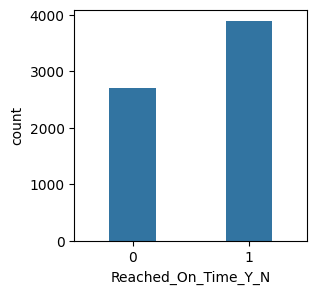

Reached_On_Time_Y_N
1    3901
0    2698
Name: count, dtype: int64

In [53]:
fig = plt.figure(figsize=(3, 3))
sns.barplot(y_train.value_counts(), width=0.4)
plt.show()
y_train.value_counts()

### Training Model

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
classWeight_ = None

In [56]:
model = LogisticRegression(class_weight=classWeight_)

In [57]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Evaluating Model

In [58]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from collections import Counter

In [59]:
predictions = model.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.40      0.46      1738
           1       0.67      0.78      0.72      2662

    accuracy                           0.63      4400
   macro avg       0.61      0.59      0.59      4400
weighted avg       0.62      0.63      0.62      4400



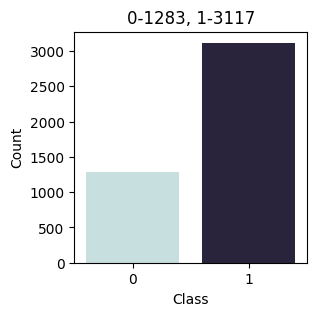

In [60]:
print("Classification Report:")
print(classification_report(y_test, predictions))

fig = plt.figure(figsize=(3, 3))
sns.barplot(data=Counter(predictions), palette=pallete)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title(f"0-{Counter(predictions)[0]}, 1-{Counter(predictions)[1]}")
plt.show()

### Tuning The Model

In [61]:
classWeight_ = {
    0: 1.4,
    1: 1
}

In [62]:
model = LogisticRegression(class_weight=classWeight_)

In [63]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1.4, 1: 1}"
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
predictions = model.predict(X_test)

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.63      0.57      1738
           1       0.72      0.63      0.68      2662

    accuracy                           0.63      4400
   macro avg       0.63      0.63      0.63      4400
weighted avg       0.65      0.63      0.64      4400



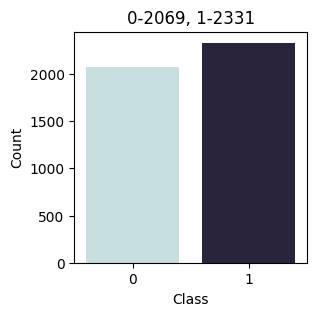

In [65]:
print("Classification Report")
print(classification_report(y_test, predictions))

fig = plt.figure(figsize=(3, 3))
sns.barplot(data=Counter(predictions), palette=pallete)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title(f"0-{Counter(predictions)[0]}, 1-{Counter(predictions)[1]}")
plt.show()

Feature Importance

In [66]:
log_odds_ratio = model.coef_[0]
odds_ratio = np.exp(log_odds_ratio)

In [67]:
for i in range(len(X_test.columns)):
    print(f"Log odds for ratio {X_test.columns[i]}: {odds_ratio[i]:.2f}")

Log odds for ratio Customer_Care_Calls: 0.28
Log odds for ratio Customer_Rating: 1.11
Log odds for ratio Cost_Of_The_Product: 0.43
Log odds for ratio Prior_Purchases: 0.31
Log odds for ratio Gender: 1.00
Log odds for ratio Weight_In_Gms: 0.05
Log odds for ratio Warehouse_Block_A: 1.23
Log odds for ratio Warehouse_Block_B: 1.35
Log odds for ratio Warehouse_Block_C: 1.38
Log odds for ratio Warehouse_Block_D: 1.26
Log odds for ratio Warehouse_Block_F: 1.30
Log odds for ratio Mode_Of_Shipment_Flight: 1.61
Log odds for ratio Mode_Of_Shipment_Road: 1.47
Log odds for ratio Mode_Of_Shipment_Ship: 1.59
Log odds for ratio Product_Importance_high: 2.00
Log odds for ratio Product_Importance_low: 1.36
Log odds for ratio Product_Importance_medium: 1.38


In [68]:
feature_odds_ratio = pd.DataFrame(data={
    'Feature': X_train.columns,
    'Odds_Ratio': odds_ratio
})
feature_odds_ratio.Odds_Ratio = feature_odds_ratio.Odds_Ratio.round(2)

In [69]:
feature_odds_ratio

,Feature,Odds_Ratio
0,Customer_Care_Calls,0.28
1,Customer_Rating,1.11
2,Cost_Of_The_Product,0.43
3,Prior_Purchases,0.31
4,Gender,1.00
5,Weight_In_Gms,0.05
6,Warehouse_Block_A,1.23
7,Warehouse_Block_B,1.35
8,Warehouse_Block_C,1.38
9,Warehouse_Block_D,1.26


| Metric           | Value | Interpretation                  |
|------------------|-------|-----------------------------------|
| Delay Recall     | 0.82  | Proportion of delayed shipments captured before they happen |
| Delay Precision  | 0.55  | Proportion of flagged delays that are real |
| On-Time Recall   | 0.55  | Proportion of actual on-time shipments recognized |
| F1 (Delayed)     | 0.66  | Overall quality in delay prediction |


The model delivers actionable, early warning for most likely-to-delay shipments, supporting proactive intervention.

### Recommendations

- Focus on flagged delayed shipments for operational intervention.
- Collect more features related to logistics, weather, and customer complaints to further boost recall and precision.
